In [2]:
# The final notebook predicts default,
# evaluates probability quality,
# calibrates probabilities,
# and studies how concentrated expected default risk is.

from pathlib import Path
import sys

import mlflow
import mlflow.sklearn

mlflow.set_experiment("amex-credit-risk")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve,
)

from sklearn.frozen import FrozenEstimator


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(
        str(PROJECT_ROOT)
    )


from src.modeling import (
    load_features,
    prepare_xy,
    split_data,
    create_models,
    train_models,
)

from src.metrics import (
    classification_metrics,
    expected_default_hhi,
    concentration_gini,
    pareto_risk_summary,
)


PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)


In [3]:
df = load_features()


X, y, feature_columns = (
    prepare_xy(
        df
    )
)


split = split_data(
    X,
    y,
)

Loaded 458,913 customer feature rows.
Predictor count: 83
Train: 293,704
Calibration: 73,426
Test: 91,783


In [4]:
models = create_models()


trained_models = train_models(
    models,
    split[
        "X_train"
    ],
    split[
        "y_train"
    ],
)

Training logistic_regression...
Training random_forest...


In [5]:
# AUC measures ranking quality.
# Average precision is useful because defaults are the minority class.
# Brier score and log loss measure probability quality.

model_results = []


for name, model in trained_models.items():

    probabilities = (
        model.predict_proba(
            split[
                "X_test"
            ]
        )[:, 1]
    )

    scores = classification_metrics(
        split[
            "y_test"
        ],
        probabilities,
    )

    scores[
        "model"
    ] = name

    model_results.append(
        scores
    )


model_results = (
    pd.DataFrame(
        model_results
    )
    .sort_values(
        "auc",
        ascending=False,
    )
)


model_results

,auc,average_precision,brier_score,log_loss,model
0,0.953502,0.877964,0.087104,0.284327,logistic_regression
1,0.949259,0.865052,0.094985,0.297223,random_forest


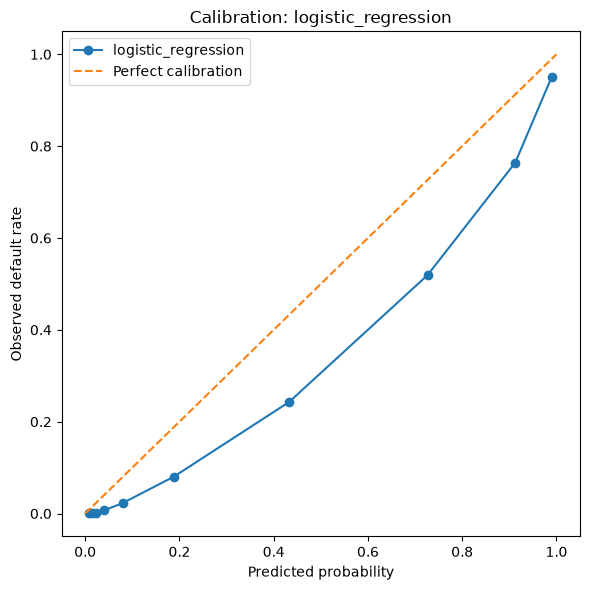

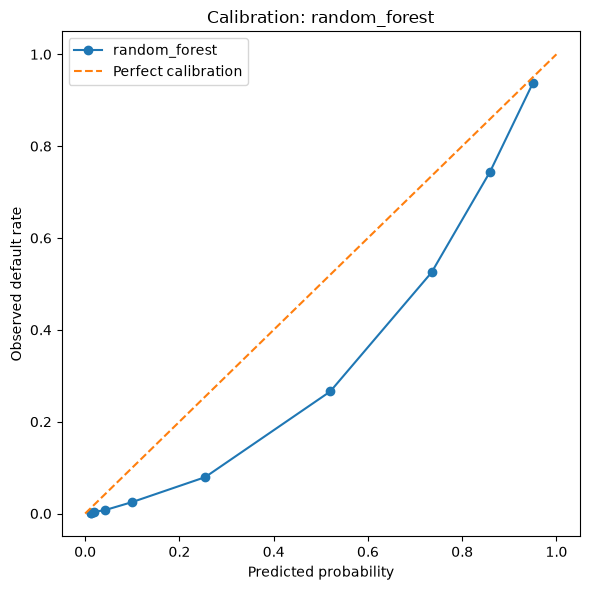

In [6]:
for name, model in trained_models.items():

    probabilities = (
        model.predict_proba(
            split[
                "X_test"
            ]
        )[:, 1]
    )

    observed, predicted = (
        calibration_curve(
            split[
                "y_test"
            ],
            probabilities,
            n_bins=10,
            strategy="quantile",
        )
    )

    plt.figure(
        figsize=(6, 6)
    )

    plt.plot(
        predicted,
        observed,
        marker="o",
        label=name,
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )

    plt.xlabel(
        "Predicted probability"
    )

    plt.ylabel(
        "Observed default rate"
    )

    plt.title(
        f"Calibration: {name}"
    )

    plt.legend()

    plt.tight_layout()
    plt.show()

In [7]:
# We choose the strongest raw ranking model,
# then compare Platt and isotonic recalibration.

best_model_name = (
    model_results.iloc[
        0
    ][
        "model"
    ]
)


best_model = (
    trained_models[
        best_model_name
    ]
)


print(
    "Model selected for calibration:",
    best_model_name,
)

Model selected for calibration: logistic_regression


In [8]:
# sklearn 1.6+ removed cv="prefit".
# FrozenEstimator keeps the already-trained model fixed
# so only the calibration mapping is fit on the calibration split.
platt = CalibratedClassifierCV(
    estimator=FrozenEstimator(best_model),
    method="sigmoid",
)


isotonic = CalibratedClassifierCV(
    estimator=FrozenEstimator(best_model),
    method="isotonic",
)


platt.fit(
    split[
        "X_calibration"
    ],
    split[
        "y_calibration"
    ],
)


isotonic.fit(
    split[
        "X_calibration"
    ],
    split[
        "y_calibration"
    ],
)


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat..._state=42))]))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,[<sklearn.cali...t 0x12675ac30>]


In [9]:
raw_probability = (
    best_model.predict_proba(
        split[
            "X_test"
        ]
    )[:, 1]
)


platt_probability = (
    platt.predict_proba(
        split[
            "X_test"
        ]
    )[:, 1]
)


isotonic_probability = (
    isotonic.predict_proba(
        split[
            "X_test"
        ]
    )[:, 1]
)

In [10]:
calibration_results = []


for method, probabilities in {
    "raw":
        raw_probability,

    "platt":
        platt_probability,

    "isotonic":
        isotonic_probability,

}.items():

    metrics = classification_metrics(
        split[
            "y_test"
        ],
        probabilities,
    )

    metrics[
        "method"
    ] = method

    calibration_results.append(
        metrics
    )


calibration_results = (
    pd.DataFrame(
        calibration_results
    )
    .sort_values(
        "brier_score"
    )
)


calibration_results

,auc,average_precision,brier_score,log_loss,method
2,0.953384,0.872743,0.074989,0.239750,isotonic
1,0.953502,0.877964,0.075181,0.241521,platt
0,0.953502,0.877964,0.087104,0.284327,raw


In [11]:
# The lowest Brier score becomes our portfolio probability
# because later risk concentration analysis requires useful probabilities.

best_method = (
    calibration_results.iloc[
        0
    ][
        "method"
    ]
)


if best_method == "platt":

    final_probability = (
        platt_probability
    )

    final_model = (
        platt
    )

elif best_method == "isotonic":

    final_probability = (
        isotonic_probability
    )

    final_model = (
        isotonic
    )

else:

    final_probability = (
        raw_probability
    )

    final_model = (
        best_model
    )


print(
    "Probability method selected:",
    best_method,
)

Probability method selected: isotonic


In [12]:
with mlflow.start_run(run_name=f"{best_model_name}_{best_method}"):

    mlflow.log_param("base_model", best_model_name)
    mlflow.log_param("calibration_method", best_method)

    final_metrics = classification_metrics(
        split["y_test"],
        final_probability
    )

    mlflow.log_metrics({
        "test_auc": float(final_metrics["auc"]),
        "test_average_precision": float(final_metrics["average_precision"]),
        "test_brier_score": float(final_metrics["brier_score"]),
        "test_log_loss": float(final_metrics["log_loss"]),
    })

    mlflow.sklearn.log_model(
        final_model,
        name="model",
        serialization_format="cloudpickle"
    )

    print("MLflow run logged successfully.")
    print(final_metrics)

2026/09/09 22:47:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged successfully.
{'auc': 0.9533844083518774, 'average_precision': 0.8727430665593428, 'brier_score': 0.07498937092229033, 'log_loss': 0.23975013078729004}


In [13]:
# X_test preserves the original feature dataframe index,
# so we can map predictions back to customer IDs.

test_index = (
    split[
        "X_test"
    ].index
)


predictions = pd.DataFrame(
    {
        "customer_ID":
            df.loc[
                test_index,
                "customer_ID",
            ].values,

        "target":
            split[
                "y_test"
            ].values,

        "predicted_default_probability":
            final_probability,
    }
)


predictions.head()

,customer_ID,target,predicted_default_probability
0,ff6959bbee24473739e37e95d74a01d2b17ff02f9295ba...,1,0.473945
1,146da2a0361d9162c4ebdc773064609c6b501abf3a06f1...,0,0.036873
2,6e92ac0c8125cb815b08dbc2e6a5a961714731478ba39f...,0,0.001740
3,1989c2eebc9151a93d84aeb4e837bd3c129a232bb1b520...,0,0.001740
4,819c0705dec6125d73e54c6eab9664e680f3b7f372a312...,1,0.189312


In [14]:
# Risk deciles make model output easier to use for portfolio analysis.

predictions[
    "risk_decile"
] = pd.qcut(
    predictions[
        "predicted_default_probability"
    ].rank(
        method="first"
    ),
    q=10,
    labels=[
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10,
    ],
)

In [15]:
segment_summary = (
    predictions
    .groupby(
        "risk_decile",
        observed=True,
        as_index=False,
    )
    .agg(
        customers=(
            "customer_ID",
            "count",
        ),

        average_predicted_pd=(
            "predicted_default_probability",
            "mean",
        ),

        observed_default_rate=(
            "target",
            "mean",
        ),

        expected_defaults=(
            "predicted_default_probability",
            "sum",
        ),
    )
)


segment_summary

,risk_decile,customers,average_predicted_pd,observed_default_rate,expected_defaults
0,1,9179,0.001468,0.000980,13.477442
1,2,9178,0.001849,0.001090,16.967971
2,3,9178,0.003701,0.001852,33.965799
3,4,9178,0.007427,0.006864,68.167553
4,5,9179,0.025145,0.023314,230.801867
5,6,9178,0.076295,0.079320,700.234473
6,7,9178,0.247924,0.243081,2275.448077
7,8,9178,0.512346,0.518087,4702.314630
8,9,9178,0.758328,0.764655,6959.931420
9,10,9179,0.946763,0.950103,8690.337722


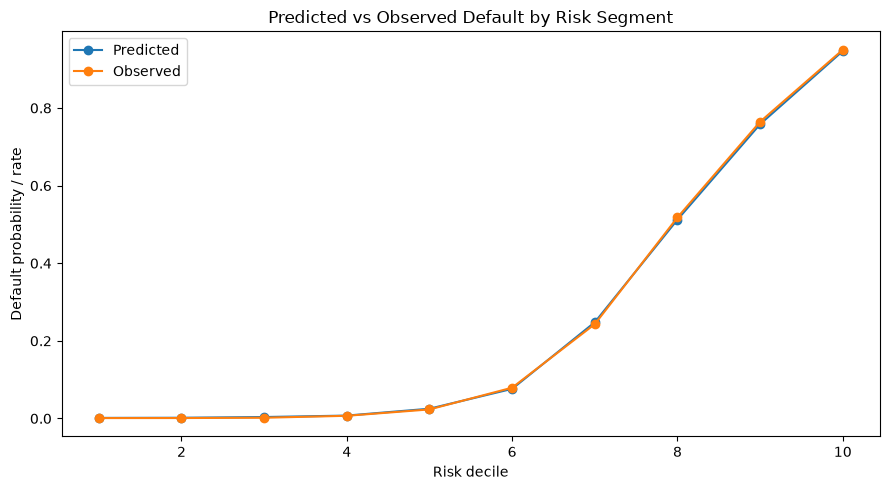

In [16]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    segment_summary[
        "risk_decile"
    ],
    segment_summary[
        "average_predicted_pd"
    ],
    marker="o",
    label="Predicted",
)

plt.plot(
    segment_summary[
        "risk_decile"
    ],
    segment_summary[
        "observed_default_rate"
    ],
    marker="o",
    label="Observed",
)

plt.xlabel(
    "Risk decile"
)

plt.ylabel(
    "Default probability / rate"
)

plt.title(
    "Predicted vs Observed Default by Risk Segment"
)

plt.legend()

plt.tight_layout()
plt.show()

In [17]:
# HHI measures how much expected-default contribution
# is concentrated across our ten risk segments.

hhi = expected_default_hhi(
    predictions,
    probability_column=
        "predicted_default_probability",
    segment_column=
        "risk_decile",
)


print(
    "Expected-default HHI:",
    round(
        hhi,
        4,
    ),
)

Expected-default HHI: 0.2704


In [18]:
# Gini provides a customer-level concentration measure.

gini = concentration_gini(
    predictions[
        "predicted_default_probability"
    ]
)


print(
    "Expected-default concentration Gini:",
    round(
        gini,
        4,
    ),
)

Expected-default concentration Gini: 0.6692


In [19]:
# Pareto analysis answers questions such as:
# what fraction of expected defaults sits inside the top 10% highest-risk customers?

pareto_summary = pareto_risk_summary(
    predictions,
    probability_column=
        "predicted_default_probability",
)


pareto_summary

,top_customer_pct,customers,expected_default_share_pct
0,1.0,918,3.867591
1,5.0,4590,18.987691
2,10.0,9179,36.681020
3,20.0,18357,66.058173


In [20]:
ranked = (
    predictions
    .sort_values(
        "predicted_default_probability",
        ascending=False,
    )
    .reset_index(drop=True)
)


ranked[
    "customer_share"
] = (
    np.arange(
        1,
        len(ranked) + 1,
    )
    / len(ranked)
)


ranked[
    "cumulative_risk_share"
] = (
    ranked[
        "predicted_default_probability"
    ]
    .cumsum()
    / ranked[
        "predicted_default_probability"
    ].sum()
)

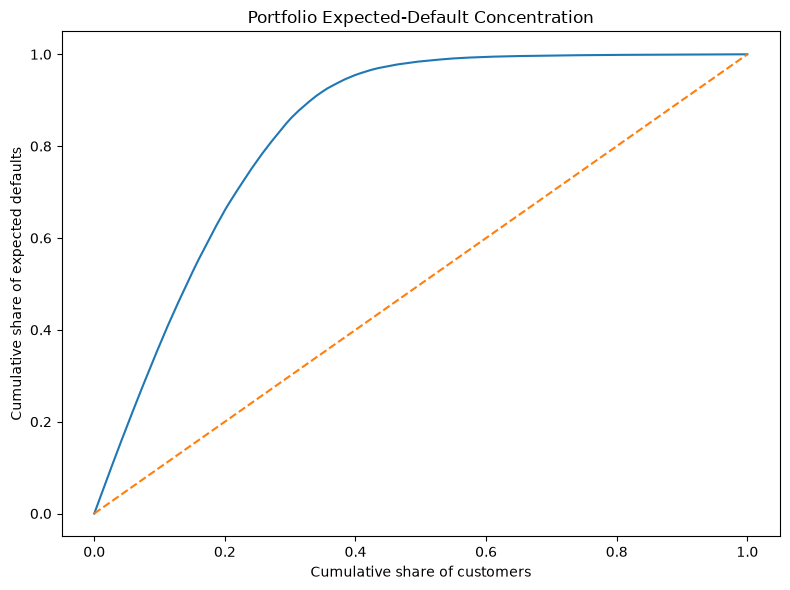

In [21]:
plt.figure(
    figsize=(8, 6)
)

plt.plot(
    ranked[
        "customer_share"
    ],
    ranked[
        "cumulative_risk_share"
    ],
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

plt.xlabel(
    "Cumulative share of customers"
)

plt.ylabel(
    "Cumulative share of expected defaults"
)

plt.title(
    "Portfolio Expected-Default Concentration"
)

plt.tight_layout()
plt.show()

In [22]:
# These files become inputs for the future Streamlit or Power BI dashboard.

predictions.to_parquet(
    PROCESSED_DIR
    / "predictions.parquet",
    index=False,
)


segment_summary.to_csv(
    PROCESSED_DIR
    / "risk_segment_summary.csv",
    index=False,
)


pareto_summary.to_csv(
    PROCESSED_DIR
    / "risk_pareto_summary.csv",
    index=False,
)


calibration_results.to_csv(
    PROCESSED_DIR
    / "calibration_comparison.csv",
    index=False,
)


model_path = (
    PROCESSED_DIR
    / "models"
    / "final_calibrated_model.joblib"
)


model_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)


joblib.dump(
    final_model,
    model_path,
)


print(
    "Final modeling and portfolio outputs saved."
)

Final modeling and portfolio outputs saved.


## Summary

This notebook builds customer-level default models, recalibrates probabilities, and measures expected-default concentration on a held-out test set.

**What we did**
- Loaded `customer_features.parquet` (**458,913** customers, 83 predictors after dropping IDs/dates/target).
- Split **train 293,704 / calibration 73,426 / test 91,783**. The test set was not used to fit calibration.
- Trained logistic regression and random forest (imputation inside the pipeline).
- Compared AUC, average precision, Brier score, and log loss; plotted calibration curves.
- Recalibrated the strongest raw model with Platt and isotonic on the **calibration** split only (`FrozenEstimator` so the base model is not refit).
- Chose the method with the lowest Brier score, scored test customers, built risk deciles, and computed expected-default HHI, concentration Gini, and Pareto shares.

**Results**
- Raw test ranking: logistic regression AUC **0.9535**, AP **0.8780**, Brier **0.0871**; random forest AUC **0.9493**, AP **0.8651**, Brier **0.0950**.
- Model selected for calibration: **logistic regression**.
- Probability comparison (test): isotonic Brier **0.0750**, Platt **0.0752**, raw **0.0871**. Selected method: **isotonic**.
- Risk deciles: predicted PD rises from **0.0015** (decile 1) to **0.947** (decile 10); observed default rates **0.0010** to **0.950**.
- Concentration: expected-default HHI **0.2704**; Gini **0.6692**.
- Pareto (share of expected defaults): top 1% **3.87%**, top 5% **18.99%**, top 10% **36.68%**, top 20% **66.06%**.

Outputs: `predictions.parquet`, `risk_segment_summary.csv`, `risk_pareto_summary.csv`, `calibration_comparison.csv`, `models/final_calibrated_model.joblib`.